# Predictive modeling & Monte Carlo simulation — FIFA World Cup 2026

This notebook implements the **CIS 3517** project plan:

- **Supervised classification**: Home win / Draw / Away win on international matches  
- **Features**: pre-match Elo (`eloratings.csv`), recent form, head-to-head, neutral venue, plus injury flags for 2026 fixtures  
- **Evaluation**: Accuracy, Precision, Recall, F1 (macro & weighted), confusion matrix  
- **Simulation**: Poisson-style goals for group tie-breakers, then **full knockout bracket** (R32 → final) using Wikipedia’s 2026 FIFA match wiring  

Helpers: `wc2026_simulation_utils.py`. Original `WC2026.ipynb` is **not** modified.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
)
from sklearn.model_selection import train_test_split

import wc2026_simulation_utils as wu

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")

ROOT = Path(".").resolve()
DATA = ROOT / "data"

## 1. Load data

We use three CSVs:

- `results.csv` — historical internationals  
- `eloratings.csv` — daily Elo snapshots  
- `future_match_probabilities_baseline.csv` — 2026 groups + baseline probabilities / injury flags  

In [2]:
results_raw = pd.read_csv(DATA / "results.csv")
elo_raw = pd.read_csv(DATA / "eloratings.csv")
wc2026_fixtures = pd.read_csv(DATA / "future_match_probabilities_baseline.csv")

former = wu.load_former_name_map(DATA / "former_names.csv")

results_raw["date"] = pd.to_datetime(results_raw["date"])
elo_raw["date"] = pd.to_datetime(elo_raw["date"], format="mixed", dayfirst=False)

results_raw["home_team"] = results_raw["home_team"].map(lambda x: wu.to_elo_team(x, former))
results_raw["away_team"] = results_raw["away_team"].map(lambda x: wu.to_elo_team(x, former))
elo_raw["team"] = elo_raw["team"].map(lambda x: wu.to_elo_team(x, former))

results_raw.head(), elo_raw.head(), wc2026_fixtures.head(3)

(        date home_team away_team  home_score  away_score tournament     city  \
 0 1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
 1 1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
 2 1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
 3 1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
 4 1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   
 
     country  neutral  
 0  Scotland    False  
 1   England    False  
 2  Scotland    False  
 3   England    False  
 4  Scotland    False  ,
         date      team  rating  change
 0 1872-11-30   England  2003.0       3
 1 1872-11-30  Scotland  1997.0      -3
 2 1873-03-08   England  2014.0      11
 3 1873-03-08  Scotland  1986.0     -11
 4 1874-03-07   England  2006.0      -8,
   group home_team       away_team  date                   tournament  \
 0     A    Mexico    South Africa   NaN  FIFA World 

## 2. Clean & scope the modeling set

- Keep **non-friendly** matches from **1998-01-01** onward (adjustable).  
- Target: `2` home win, `1` draw, `0` away win.  
- Encode `neutral` as 0/1. Injuries are **not** in historical data → use `0` in training; baseline CSV supplies flags for 2026.

In [3]:
CUTOFF_START = pd.Timestamp("1998-01-01")

matches = results_raw[
    (results_raw["date"] >= CUTOFF_START) & (results_raw["tournament"] != "Friendly")
].copy()

conds = [
    matches["home_score"] > matches["away_score"],
    matches["home_score"] == matches["away_score"],
    matches["home_score"] < matches["away_score"],
]
matches["target"] = np.select(conds, [2, 1, 0], default=1)
matches["neutral_int"] = matches["neutral"].astype(str).str.upper().eq("TRUE").astype(int)

matches = matches.sort_values("date").reset_index(drop=True)
len(matches), matches["target"].value_counts(normalize=True).round(3)

(17871,
 target
 2    0.483
 0    0.299
 1    0.219
 Name: proportion, dtype: float64)

## 3. Feature engineering (leakage-safe)

1. **Elo at kickoff** — `merge_asof` last rating on/before match date for home & away.  
2. **Rolling form & H2H** — `add_rolling_features_fast` uses only *prior* matches.  

Rows with missing Elo (new/obscure teams) are dropped for training.

In [4]:
ROLL_WINDOW = 10

feat = wu.merge_asof_elo(matches, elo_raw)
feat["elo_diff"] = feat["elo_home"] - feat["elo_away"]
feat = wu.add_rolling_features_fast(feat, window=ROLL_WINDOW)
feat["home_injury"] = 0
feat["away_injury"] = 0

before = len(feat)
feat = feat.dropna(subset=["elo_home", "elo_away"])
print(f"dropped missing-Elo rows: {before - len(feat)}")

FEATURE_COLS = [
    "elo_home",
    "elo_away",
    "elo_diff",
    "neutral_int",
    "form_pts_home",
    "form_gd_home",
    "form_pts_away",
    "form_gd_away",
    "h2h_home_points_avg",
    "home_injury",
    "away_injury",
]

feat[["date", "home_team", "away_team", "target"] + FEATURE_COLS].head()

dropped missing-Elo rows: 6461


,date,home_team,away_team,target,elo_home,elo_away,elo_diff,neutral_int,form_pts_home,form_gd_home,form_pts_away,form_gd_away,h2h_home_points_avg,home_injury,away_injury
0,1998-01-10,Malawi,Zambia,0,1425.0,1616.0,-191.0,0,0.0,0.0,0.0,0.0,1.0,0,0
1,1998-01-18,Lesotho,Zimbabwe,0,1164.0,1495.0,-331.0,0,0.0,0.0,0.0,0.0,1.0,0,0
4,1998-01-25,Thailand,Egypt,1,1447.0,1616.0,-169.0,0,0.0,0.0,0.0,0.0,1.0,0,0
6,1998-01-28,Iran,Nigeria,0,1536.0,1622.0,-86.0,1,0.0,0.0,0.0,0.0,1.0,0,0
9,1998-01-31,Egypt,South Korea,1,1536.0,1724.0,-188.0,1,0.5,-1.0,3.0,2.0,0.0,0,0


## 4. Exploratory analysis (EDA)

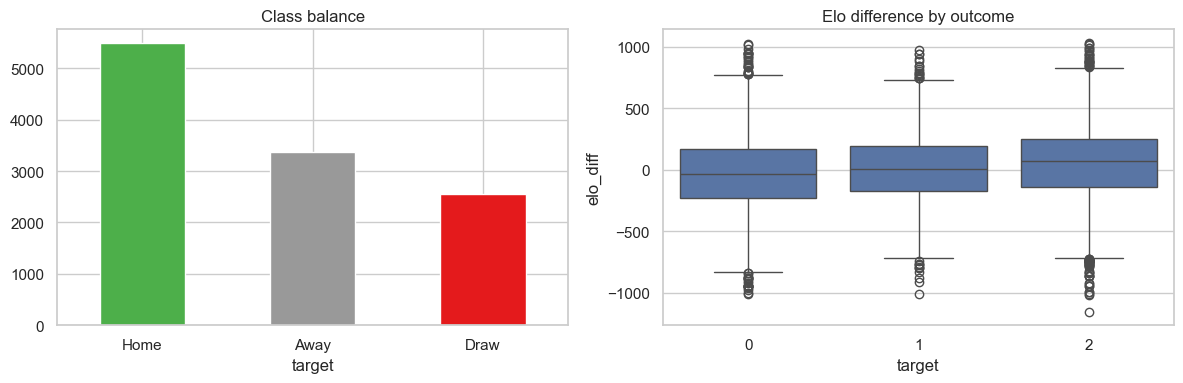

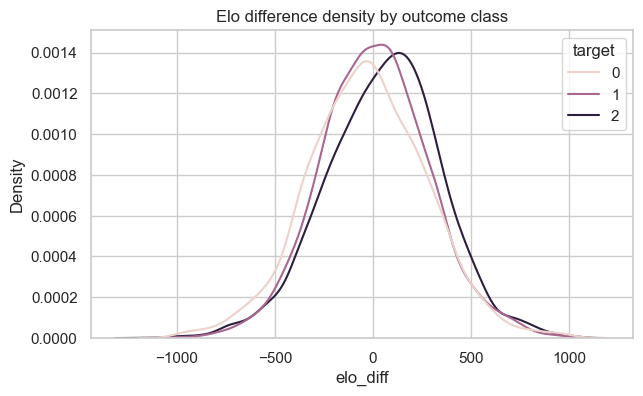

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feat["target"].map({0: "Away", 1: "Draw", 2: "Home"}).value_counts().plot(
    kind="bar", ax=axes[0], title="Class balance", color=["#4daf4a", "#999999", "#e41a1c"]
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.boxplot(data=feat, x="target", y="elo_diff", ax=axes[1])
axes[1].set_title("Elo difference by outcome")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.kdeplot(data=feat, x="elo_diff", hue="target", common_norm=False)
plt.title("Elo difference density by outcome class")
plt.show()

## 5. Chronological train / validation / test split

Random splits inflate metrics because neighboring matches leak form.  
Here: **train ≤ 2016-12-31**, **val = 2017–2019**, **test ≥ 2020**.

In [6]:
TRAIN_END = pd.Timestamp("2016-12-31")
VAL_END = pd.Timestamp("2019-12-31")

train_idx = feat["date"] <= TRAIN_END
val_idx = (feat["date"] > TRAIN_END) & (feat["date"] <= VAL_END)
test_idx = feat["date"] > VAL_END

X_train, y_train = feat.loc[train_idx, FEATURE_COLS], feat.loc[train_idx, "target"]
X_val, y_val = feat.loc[val_idx, FEATURE_COLS], feat.loc[val_idx, "target"]
X_test, y_test = feat.loc[test_idx, FEATURE_COLS], feat.loc[test_idx, "target"]

X_train.shape, X_val.shape, X_test.shape

((7169, 11), (1268, 11), (2977, 11))

## 6. Models

We fit three classifiers:

| Model | Role |
|-------|------|
| Multinomial **Logistic Regression** | interpretable baseline + calibrated-ish probabilities |
| **RandomForest** | nonlinear ensemble (proposal reference) |
| **HistGradientBoosting** | strong default GBDT in scikit-learn |

The **primary model** used later for Monte Carlo is the validation **macro-F1** winner.

In [7]:
models = {
    "logreg": LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
    ),
    "rf": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=1,
    ),
    "hgb": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_depth=5,
        max_iter=400,
        class_weight="balanced",
        random_state=42,
    ),
}

trained = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    trained[name] = clf


def report_split(name: str, clf, X, y, label: str) -> None:
    pred = clf.predict(X)
    print(f"\n=== {name} — {label} ===")
    print("Accuracy:", round(float(accuracy_score(y, pred)), 4))
    print(
        "Precision macro:",
        round(float(precision_score(y, pred, average="macro", labels=[0, 1, 2], zero_division=0)), 4),
    )
    print(
        "F1 macro:",
        round(float(f1_score(y, pred, average="macro", labels=[0, 1, 2], zero_division=0)), 4),
    )
    print(classification_report(y, pred, labels=[0, 1, 2], target_names=["Away", "Draw", "Home"], zero_division=0))

for name, clf in trained.items():
    report_split(name, clf, X_val, y_val, "validation")

best_name = max(
    trained,
    key=lambda n: f1_score(y_val, trained[n].predict(X_val), average="macro", labels=[0, 1, 2], zero_division=0),
)
clf_best = trained[best_name]
print(f"\nSelected for simulation: {best_name}")

report_split(best_name, clf_best, X_test, y_test, "held-out test")


=== logreg — validation ===
Accuracy: 0.5576
Precision macro: 0.5153
F1 macro: 0.5157
              precision    recall  f1-score   support

        Away       0.55      0.64      0.59       402
        Draw       0.30      0.29      0.29       277
        Home       0.70      0.63      0.66       589

    accuracy                           0.56      1268
   macro avg       0.52      0.52      0.52      1268
weighted avg       0.56      0.56      0.56      1268


=== rf — validation ===
Accuracy: 0.5355
Precision macro: 0.4417
F1 macro: 0.4168
              precision    recall  f1-score   support

        Away       0.53      0.49      0.51       402
        Draw       0.23      0.05      0.08       277
        Home       0.56      0.79      0.65       589

    accuracy                           0.54      1268
   macro avg       0.44      0.45      0.42      1268
weighted avg       0.48      0.54      0.48      1268


=== hgb — validation ===
Accuracy: 0.5118
Precision macro: 0.4797
F

### Confusion matrix (test) & probability metrics

multiclass log loss (lower is better): 0.957


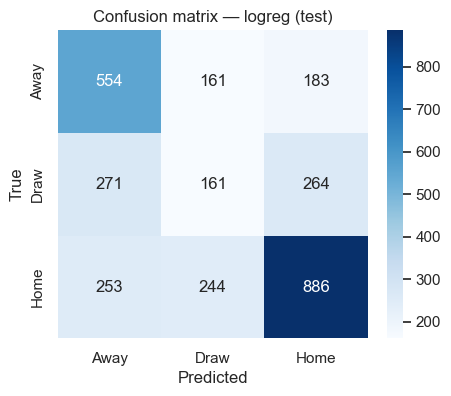

In [8]:
proba = clf_best.predict_proba(X_test)
try:
    ll = log_loss(y_test, proba, labels=[0, 1, 2])
    print("multiclass log loss (lower is better):", round(float(ll), 4))
except ValueError as e:
    print("log_loss skipped:", e)

cm = confusion_matrix(y_test, clf_best.predict(X_test), labels=[0, 1, 2])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Away", "Draw", "Home"], yticklabels=["Away", "Draw", "Home"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix — {best_name} (test)")
plt.show()

## 7. Goal model (Poisson) for simulated scores

Independent Poisson regressors for `home_score` and `away_score` using:

- `elo_diff`, `neutral_int`

Sampling goals feeds **points → GD → GF** tie-breakers in groups. (Knockout draws go to extra-time coin-flip weighted by Elo, see utils.)

In [9]:
train_goal = feat.loc[train_idx]

Xg = train_goal[["elo_diff", "neutral_int"]].to_numpy()
pr_home = PoissonRegressor(max_iter=300, alpha=1e-3)
pr_away = PoissonRegressor(max_iter=300, alpha=1e-3)
pr_home.fit(Xg, train_goal["home_score"])
pr_away.fit(Xg, train_goal["away_score"])


def sample_goals_poisson(ht: str, at: str, elo_h: float, elo_a: float, neutral: bool) -> tuple[int, int]:
    diff = elo_h - elo_a
    z = np.array([[diff, float(neutral)]])
    lam_h = float(np.clip(pr_home.predict(z)[0], 0.15, 5.5))
    lam_a = float(np.clip(pr_away.predict(z)[0], 0.15, 5.5))
    return int(np.random.poisson(lam_h)), int(np.random.poisson(lam_a))

## 8. Monte Carlo tournament simulation (2026)

1. Pull **recent form** as-of the last `results.csv` date.  
2. Build classifier feature rows for every line in `future_match_probabilities_baseline.csv` (group stage matchups).  
3. Repeatedly:
   - simulate six group matches per letter with `sample_goals_poisson`  
   - advance **top 2 + best 8 third-place teams** (FIFA-style ranking)  
   - run knockout bracket (`wu.run_full_knockout`)  

> **Note:** Third-place *slot assignment* uses combinatorial backtracking in `wc2026_simulation_utils.py`—close to FIFA’s restrictions, but not every bracket lock scenario is enumerated.

In [10]:
FORM_CUTOFF = matches["date"].max() + pd.Timedelta(seconds=1)
hist = matches[matches["date"] < FORM_CUTOFF].copy()
form_df = wu.latest_form_per_team(matches, FORM_CUTOFF, ROLL_WINDOW)
form_lookup = form_df.set_index("team")


def h2h_home_ppg(home_team: str, away_team: str, k: int = 5) -> float:
    sub = hist[
        ((hist["home_team"] == home_team) & (hist["away_team"] == away_team))
        | ((hist["home_team"] == away_team) & (hist["away_team"] == home_team))
    ].sort_values("date")
    if sub.empty:
        return 1.0
    pts = []
    for _, r in sub.tail(k).iterrows():
        if r["home_team"] == home_team:
            if r["home_score"] > r["away_score"]:
                pts.append(3)
            elif r["home_score"] == r["away_score"]:
                pts.append(1)
            else:
                pts.append(0)
        else:
            if r["away_score"] > r["home_score"]:
                pts.append(3)
            elif r["away_score"] == r["home_score"]:
                pts.append(1)
            else:
                pts.append(0)
    return float(np.mean(pts))


def canon_team(x: str) -> str:
    return wu.to_elo_team(wu.normalize_team_name(x), former)


rows = []
fx = wc2026_fixtures.copy()
for _, r in fx.iterrows():
    ht = canon_team(str(r["home_team"]))
    at = canon_team(str(r["away_team"]))
    eh = float(r["home_elo"]) if pd.notna(r["home_elo"]) else 1500.0
    ea = float(r["away_elo"]) if pd.notna(r["away_elo"]) else 1500.0
    fh = form_lookup.loc[ht] if ht in form_lookup.index else None
    fa = form_lookup.loc[at] if at in form_lookup.index else None
    fph = float(fh["form_pts"]) if fh is not None else 1.0
    fgh = float(fh["form_gd"]) if fh is not None else 0.0
    fpa = float(fa["form_pts"]) if fa is not None else 1.0
    fga = float(fa["form_gd"]) if fa is not None else 0.0
    h2h = h2h_home_ppg(ht, at)
    rows.append(
        {
            "group": r["group"],
            "home_team": ht,
            "away_team": at,
            "elo_home": eh,
            "elo_away": ea,
            "home_elo": eh,
            "away_elo": ea,
            "elo_diff": eh - ea,
            "neutral_int": 1,
            "form_pts_home": fph,
            "form_gd_home": fgh,
            "form_pts_away": fpa,
            "form_gd_away": fga,
            "h2h_home_points_avg": h2h,
            "home_injury": int(r.get("home_injury_flag", 0) or 0),
            "away_injury": int(r.get("away_injury_flag", 0) or 0),
        }
    )

wc_features = pd.DataFrame(rows)

wc_proba = pd.DataFrame(
    clf_best.predict_proba(wc_features[FEATURE_COLS]),
    columns=["p_away", "p_draw", "p_home"],
)
wc_preview = pd.concat(
    [wc_features[["group", "home_team", "away_team"]], wc_proba], axis=1
)
wc_preview.head(10)

,group,home_team,away_team,p_away,p_draw,p_home
0,A,Mexico,South Africa,0.285499,0.388861,0.325640
1,A,Mexico,South Korea,0.361321,0.399083,0.239596
2,A,Mexico,UEFA Playoff D,0.214488,0.359574,0.425938
3,A,South Africa,South Korea,0.534996,0.343062,0.121942
4,A,South Africa,UEFA Playoff D,0.301545,0.363841,0.334613
5,A,South Korea,UEFA Playoff D,0.224218,0.362219,0.413563
6,B,Canada,Switzerland,0.474226,0.368265,0.157509
7,B,Canada,Qatar,0.255051,0.357217,0.387733
8,B,Canada,UEFA Playoff A,0.247953,0.364729,0.387317
9,B,Switzerland,Qatar,0.222483,0.354844,0.422673


In [11]:
from collections import Counter

N_SIMULATIONS = 2500  # increase to 10_000+ for smoother empirical probabilities

sim_fixtures = wc_features.copy()

champion_counts: Counter[str] = Counter()

for k in range(N_SIMULATIONS):
    np.random.seed(42 + k)
    standings = wu.simulate_group_stage_from_fixtures(
        sim_fixtures, sample_goals_poisson, neutral_site=True
    )
    champ = wu.run_full_knockout(standings, sample_goals_poisson)
    champion_counts[champ] += 1

champ_table = (
    pd.DataFrame(
        [{"team": t, "p": c / N_SIMULATIONS} for t, c in champion_counts.most_common()],
    )
    .sort_values("p", ascending=False)
    .reset_index(drop=True)
)
champ_table.head(15)

,team,p
0,Germany,0.0828
1,France,0.0568
2,Brazil,0.0544
3,Mexico,0.0480
4,Netherlands,0.0448
5,Argentina,0.0408
6,Spain,0.0376
7,Portugal,0.0352
8,Ivory Coast,0.0324
9,Japan,0.0308


/var/folders/vz/2b5f96hn32z7cfxwsyn10cf40000gn/T/ipykernel_31683/3544708045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topn, y="team", x="p", palette="viridis")


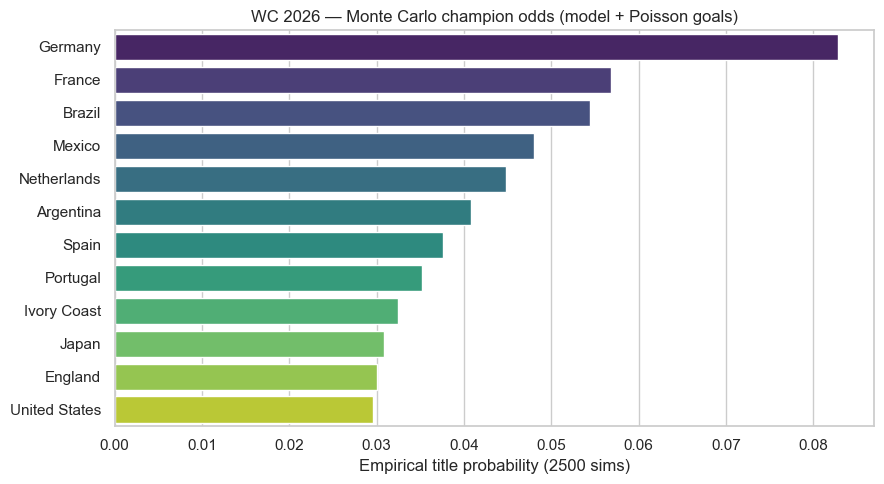

In [12]:
topn = champ_table.head(12)
plt.figure(figsize=(9, 5))
sns.barplot(data=topn, y="team", x="p", palette="viridis")
plt.xlabel(f"Empirical title probability ({N_SIMULATIONS} sims)")
plt.ylabel("")
plt.title("WC 2026 — Monte Carlo champion odds (model + Poisson goals)")
plt.tight_layout()
plt.show()

## 9. References (proposal)

- Mart J. **International football results** (Kaggle) — `results.csv`  
- Sara Zahran et al. **WC2026 match probability baseline** — `future_match_probabilities_baseline.csv`  
- **World Football Elo Ratings** — `eloratings.csv`  
- Wikipedia — **2026 FIFA World Cup knockout stage** (bracket wiring for R32→final)  